In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from scipy.cluster import hierarchy
from tem import world, model
from pathlib import Path
import itertools
import polars as pl
import seaborn as sns
import torch
from tbparse import SummaryReader
config_file = "../envs/mckenzie2024.json"
out_dir = Path("~/Dropbox/work/tem/McKenzie").expanduser() / "study-7"
out_dir.mkdir(exist_ok=True)

In [2]:
design = world.design_mckenzie(config_file, {"AB": 400, "CD": 400, "ABCD": 400})
nodes = (
    ["".join(c) for c in itertools.product(["C1", "C2"], ["AB", "BA", "CD", "DC"])]
    + ["".join(c) for c in itertools.product(["C1", "C2"], ["L", "R"], ["A", "B", "C", "D"], ["R", "N"])]
)
n_runs = 1
for run in range(1, n_runs + 1):
    world.learn_mckenzie(design, nodes, out_dir, run)

In [3]:
param_file = out_dir / "sub-001_run-1_params.pt"
params = torch.load(param_file, weights_only=False)
tem_model = model.Model(params)
walks = world.walks_mckenzie(design, nodes, params["n_x"])

g_state = []
p_state = []
with torch.no_grad():
    for walk in walks:
        forward = tem_model(walk, prev_iter=None)
        for step in forward:
            g_module = []
            p_module = []
            # g_module.append(step.g_inf[-1][0].numpy())
            for f in range(tem_model.hyper["n_f"]):
                g_module.append(step.g_inf[f][0].numpy())
                p_module.append(step.p_inf[f][0].numpy())
            g_state.append(np.concat(g_module))
            p_state.append(np.concat(p_module))
g = np.vstack(g_state)
p = np.vstack(p_state)

In [4]:
subject = "001"
reader = SummaryReader(str(out_dir))
df = (
    pl.DataFrame(reader.scalars)
    .with_columns(
        subject=pl.lit(subject),
        run=pl.col("value").cum_count().over(pl.col("step")),
    )
    .with_columns(
        smooth_value=pl.col("value").rolling_mean(window_size=50).over("tag", "run"),
    )
)

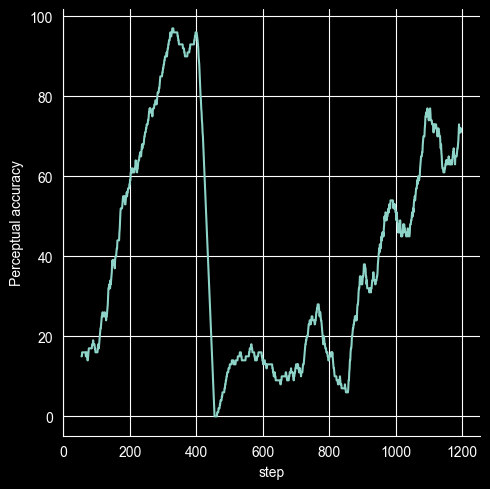

In [5]:
h = sns.relplot(
    df.filter(pl.col("tag") == "Accuracies/p"),
    x="step",
    y="smooth_value",
    kind="line",
)
h.set(ylabel="Perceptual accuracy")

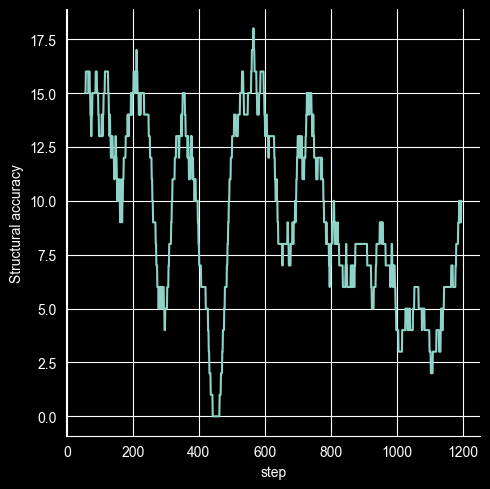

In [6]:
h = sns.relplot(
    df.filter(pl.col("tag") == "Accuracies/g"),
    x="step",
    y="smooth_value",
    kind="line",
)
h.set(ylabel="Structural accuracy")

In [7]:
nodes = (
    design.with_row_index("iteration")
    .filter(trial_type="feedback")
    .unique("node", keep="last")
    .sort("context", "object_set", "object", "action", "valence")
)
nodes

iteration,index,phase,trial,context,object_set,node,action,object,valence,trial_type
u32,u32,str,i64,str,str,str,str,str,str,str
2351,1175,"""ABCD""",376,"""C1""","""AB""","""C1LAR""","""L""","""A""","""R""","""feedback"""
2363,1181,"""ABCD""",382,"""C1""","""AB""","""C1RAR""","""R""","""A""","""R""","""feedback"""
2399,1199,"""ABCD""",400,"""C1""","""AB""","""C1LBN""","""L""","""B""","""N""","""feedback"""
2359,1179,"""ABCD""",380,"""C1""","""AB""","""C1RBN""","""R""","""B""","""N""","""feedback"""
2375,1187,"""ABCD""",388,"""C1""","""CD""","""C1LCR""","""L""","""C""","""R""","""feedback"""
…,…,…,…,…,…,…,…,…,…,…
2369,1184,"""ABCD""",385,"""C2""","""AB""","""C2RBR""","""R""","""B""","""R""","""feedback"""
2353,1176,"""ABCD""",377,"""C2""","""CD""","""C2LCN""","""L""","""C""","""N""","""feedback"""
2313,1156,"""ABCD""",357,"""C2""","""CD""","""C2RCN""","""R""","""C""","""N""","""feedback"""


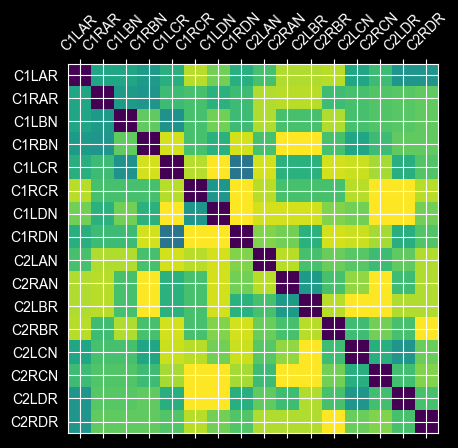

In [8]:
rdm = distance.squareform(distance.pdist(p[nodes["iteration"], :], metric="euclidean"))
fig, ax = plt.subplots()
ax.matshow(rdm, cmap="viridis")
ax.set_xticks(np.arange(len(nodes)))
ax.set_xticklabels(nodes["node"])
ax.set_yticks(np.arange(len(nodes)))
ax.set_yticklabels(nodes["node"])
ax.tick_params(axis="x", labelrotation=45)

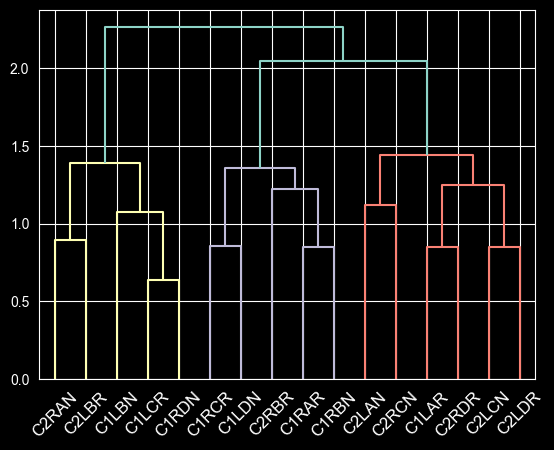

In [9]:
linkage_data = hierarchy.linkage(p[nodes["iteration"], :], method="ward", metric="euclidean")
fig, ax = plt.subplots()
hierarchy.dendrogram(linkage_data, ax=ax, labels=nodes["node"])
ax.tick_params(axis='x', labelrotation=45)

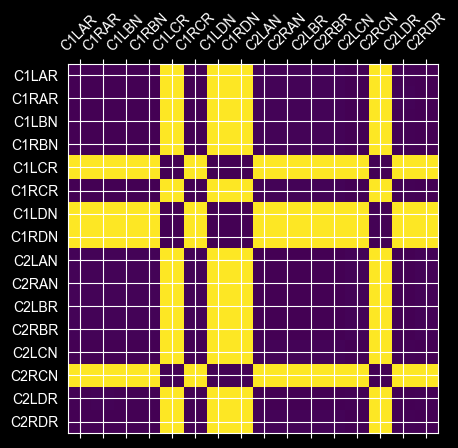

In [10]:
rdm = distance.squareform(distance.pdist(g[nodes["iteration"], :], metric="euclidean"))
fig, ax = plt.subplots()
ax.matshow(rdm, cmap="viridis")
ax.set_xticks(np.arange(len(nodes)))
ax.set_xticklabels(nodes["node"])
ax.set_yticks(np.arange(len(nodes)))
ax.set_yticklabels(nodes["node"])
ax.tick_params(axis="x", labelrotation=45)

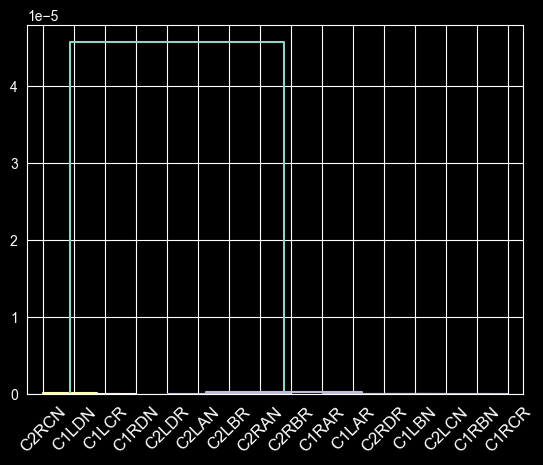

In [11]:
linkage_data = hierarchy.linkage(g[nodes["iteration"], :], method="ward", metric="euclidean")
fig, ax = plt.subplots()
hierarchy.dendrogram(linkage_data, ax=ax, labels=nodes["node"])
ax.tick_params(axis='x', labelrotation=45)